In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [129]:
df = pd.read_csv('data/flight_data_2024_sample.csv')

In [130]:
df.head(10) 

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,dest,dest_city_name,dest_state_nm,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,RAP,"Rapid City, SD",South Dakota,1018,1015.0,-3.0,21.0,1036.0,1135.0,4.0,1149,1139.0,-10.0,0,NaN,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,PHX,"Phoenix, AZ",Arizona,1637,1633.0,-4.0,14.0,1647.0,1900.0,6.0,1923,1906.0,-17.0,0,NaN,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,ATL,"Atlanta, GA",Georgia,1000,952.0,-8.0,13.0,1005.0,1034.0,8.0,1059,1042.0,-17.0,0,NaN,0,59.0,50.0,29.0,106.0,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,LAS,"Las Vegas, NV",Nevada,1330,1334.0,4.0,8.0,1342.0,1425.0,6.0,1430,1431.0,1.0,0,NaN,0,180.0,177.0,163.0,1099.0,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,MYR,"Myrtle Beach, SC",South Carolina,1340,1333.0,-7.0,16.0,1349.0,1505.0,4.0,1510,1509.0,-1.0,0,NaN,0,90.0,96.0,76.0,399.0,0,0,0,0,0
5,2024,4,15,1,2024-04-15,WN,2358.0,SAN,"San Diego, CA",California,PHX,"Phoenix, AZ",Arizona,715,708.0,-7.0,13.0,721.0,812.0,4.0,830,816.0,-14.0,0,NaN,0,75.0,68.0,51.0,304.0,0,0,0,0,0
6,2024,11,27,3,2024-11-27,G4,163.0,MLB,"Melbourne, FL",Florida,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,933,924.0,-9.0,12.0,936.0,1153.0,5.0,1202,1158.0,-4.0,0,NaN,0,149.0,154.0,137.0,914.0,0,0,0,0,0
7,2024,8,31,6,2024-08-31,AS,1269.0,BNA,"Nashville, TN",Tennessee,PDX,"Portland, OR",Oregon,1855,1850.0,-5.0,21.0,1911.0,2125.0,3.0,2155,2128.0,-27.0,0,NaN,0,300.0,278.0,254.0,1973.0,0,0,0,0,0
8,2024,4,19,5,2024-04-19,OO,3438.0,LAX,"Los Angeles, CA",California,SJC,"San Jose, CA",California,820,814.0,-6.0,29.0,843.0,932.0,5.0,939,937.0,-2.0,0,NaN,0,79.0,83.0,49.0,308.0,0,0,0,0,0
9,2024,2,8,4,2024-02-08,OO,5654.0,SFO,"San Francisco, CA",California,BFL,"Bakersfield, CA",California,2235,2227.0,-8.0,17.0,2244.0,2324.0,3.0,2350,2327.0,-23.0,0,NaN,0,75.0,60.0,40.0,238.0,0,0,0,0,0


In [131]:
df.describe().round(2)

,year,month,day_of_month,day_of_week,op_carrier_fl_num,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,9884.00,9884.00,9880.00,9880.00,9873.00,9873.00,10000.00,9873.0,9836.00,10000.00,10000.00,10000.00,9836.00,9836.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,2024.0,6.61,15.84,3.95,2529.76,1324.45,1330.16,13.00,17.88,1353.56,1460.50,8.41,1496.54,1468.1,7.55,0.01,0.00,147.37,141.73,115.45,838.35,4.87,1.08,3.03,0.01,6.14
std,0.0,3.38,8.79,2.01,1656.00,488.54,504.95,53.61,9.77,507.45,536.91,7.07,513.23,540.1,55.80,0.11,0.06,72.93,72.79,70.74,598.53,33.50,15.82,15.76,0.38,29.63
min,2024.0,1.00,1.00,1.00,1.00,22.00,1.00,-22.00,4.00,1.00,1.00,1.00,2.00,1.0,-78.00,0.00,0.00,23.00,17.00,8.00,31.00,0.00,0.00,0.00,0.00,0.00
25%,2024.0,4.00,8.00,2.00,1172.00,905.00,910.00,-6.00,12.00,928.75,1046.00,5.00,1109.00,1052.0,-15.00,0.00,0.00,93.00,89.00,64.00,404.00,0.00,0.00,0.00,0.00,0.00
50%,2024.0,7.00,16.00,4.00,2254.00,1320.00,1324.00,-2.00,15.00,1337.00,1503.00,6.00,1521.00,1508.0,-6.00,0.00,0.00,130.00,125.00,98.00,680.00,0.00,0.00,0.00,0.00,0.00
75%,2024.0,10.00,23.00,6.00,3742.00,1734.25,1745.00,9.25,21.00,1759.00,1914.00,10.00,1925.00,1921.0,10.00,0.00,0.00,179.00,174.00,145.00,1072.00,0.00,0.00,0.00,0.00,0.00
max,2024.0,12.00,31.00,7.00,8771.00,2359.00,2400.00,2011.00,154.00,2400.00,2400.00,140.00,2359.00,2400.0,2014.00,1.00,1.00,685.00,691.00,635.00,5095.00,2011.00,664.00,454.00,22.00,995.00


In [132]:

# 2. Dizionario completo per tradurre TUTTE le 35 colonne
traduzione_totale = {
    'year': 'anno',
    'month': 'mese',
    'day_of_month': 'giorno_mese',
    'day_of_week': 'giorno_settimana',
    'fl_date': 'data_volo',
    'op_unique_carrier': 'compagnia',
    'op_carrier_fl_num': 'num_volo',
    'origin': 'aeroporto_orig_cod',
    'origin_city_name': 'citta_orig',
    'origin_state_nm': 'stato_orig',
    'dest': 'aeroporto_dest_cod',
    'dest_city_name': 'citta_dest',
    'dest_state_nm': 'stato_dest',
    'crs_dep_time': 'ora_part_prevista',
    'dep_time': 'ora_part_reale',
    'dep_delay': 'ritardo_partenza',
    'taxi_out': 'tempo_rullaggio_uscita',
    'wheels_off': 'ora_decollo',
    'wheels_on': 'ora_atterraggio',
    'taxi_in': 'tempo_rullaggio_entrata',
    'crs_arr_time': 'ora_arr_prevista',
    'arr_time': 'ora_arr_reale',
    'arr_delay': 'ritardo_arrivo',
    'cancelled': 'cancellato',
    'cancellation_code': 'codice_cancellazione',
    'diverted': 'dirottato',
    'crs_elapsed_time': 'durata_prevista',
    'actual_elapsed_time': 'durata_reale',
    'air_time': 'minuti_volo_effettivi',
    'distance': 'distanza',
    'carrier_delay': 'ritardo_vettore',
    'weather_delay': 'ritardo_meteo',
    'nas_delay': 'ritardo_traffico_aereo',
    'security_delay': 'ritardo_sicurezza',
    'late_aircraft_delay': 'ritardo_aereo_precedente'
}

# 3. Applicazione della traduzione
df.rename(columns=traduzione_totale, inplace=True)

# 4. Visualizzazione delle prime 10 righe
df.head(10)

,anno,mese,giorno_mese,giorno_settimana,data_volo,compagnia,num_volo,aeroporto_orig_cod,citta_orig,stato_orig,aeroporto_dest_cod,citta_dest,stato_dest,ora_part_prevista,ora_part_reale,ritardo_partenza,tempo_rullaggio_uscita,ora_decollo,ora_atterraggio,tempo_rullaggio_entrata,ora_arr_prevista,ora_arr_reale,ritardo_arrivo,cancellato,codice_cancellazione,dirottato,durata_prevista,durata_reale,minuti_volo_effettivi,distanza,ritardo_vettore,ritardo_meteo,ritardo_traffico_aereo,ritardo_sicurezza,ritardo_aereo_precedente
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,RAP,"Rapid City, SD",South Dakota,1018,1015.0,-3.0,21.0,1036.0,1135.0,4.0,1149,1139.0,-10.0,0,NaN,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,PHX,"Phoenix, AZ",Arizona,1637,1633.0,-4.0,14.0,1647.0,1900.0,6.0,1923,1906.0,-17.0,0,NaN,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,ATL,"Atlanta, GA",Georgia,1000,952.0,-8.0,13.0,1005.0,1034.0,8.0,1059,1042.0,-17.0,0,NaN,0,59.0,50.0,29.0,106.0,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,LAS,"Las Vegas, NV",Nevada,1330,1334.0,4.0,8.0,1342.0,1425.0,6.0,1430,1431.0,1.0,0,NaN,0,180.0,177.0,163.0,1099.0,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,MYR,"Myrtle Beach, SC",South Carolina,1340,1333.0,-7.0,16.0,1349.0,1505.0,4.0,1510,1509.0,-1.0,0,NaN,0,90.0,96.0,76.0,399.0,0,0,0,0,0
5,2024,4,15,1,2024-04-15,WN,2358.0,SAN,"San Diego, CA",California,PHX,"Phoenix, AZ",Arizona,715,708.0,-7.0,13.0,721.0,812.0,4.0,830,816.0,-14.0,0,NaN,0,75.0,68.0,51.0,304.0,0,0,0,0,0
6,2024,11,27,3,2024-11-27,G4,163.0,MLB,"Melbourne, FL",Florida,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,933,924.0,-9.0,12.0,936.0,1153.0,5.0,1202,1158.0,-4.0,0,NaN,0,149.0,154.0,137.0,914.0,0,0,0,0,0
7,2024,8,31,6,2024-08-31,AS,1269.0,BNA,"Nashville, TN",Tennessee,PDX,"Portland, OR",Oregon,1855,1850.0,-5.0,21.0,1911.0,2125.0,3.0,2155,2128.0,-27.0,0,NaN,0,300.0,278.0,254.0,1973.0,0,0,0,0,0
8,2024,4,19,5,2024-04-19,OO,3438.0,LAX,"Los Angeles, CA",California,SJC,"San Jose, CA",California,820,814.0,-6.0,29.0,843.0,932.0,5.0,939,937.0,-2.0,0,NaN,0,79.0,83.0,49.0,308.0,0,0,0,0,0
9,2024,2,8,4,2024-02-08,OO,5654.0,SFO,"San Francisco, CA",California,BFL,"Bakersfield, CA",California,2235,2227.0,-8.0,17.0,2244.0,2324.0,3.0,2350,2327.0,-23.0,0,NaN,0,75.0,60.0,40.0,238.0,0,0,0,0,0


In [133]:
# 1. Vediamo quanti voli sono stati cancellati o dirottati
cancellati = df['cancellato'].sum()
dirottati = df['dirottato'].sum()

# 2. Vediamo quante celle sono completamente vuote (NaN) per ogni colonna
valori_nulli = df.isnull().sum()

# 3. Stampiamo un report per decidere
print("--- REPORT DIAGNOSTICO ---")
print(f"Voli totali nel file: {len(df)}")
print(f"Voli cancellati: {cancellati}")
print(f"Voli dirottati: {dirottati}")
print("\nConteggio valori nulli per colonna (le più critiche):")
print(valori_nulli[valori_nulli > 0]) # Mostra solo le colonne che hanno almeno un errore

--- REPORT DIAGNOSTICO ---
Voli totali nel file: 10000
Voli cancellati: 122
Voli dirottati: 42

Conteggio valori nulli per colonna (le più critiche):
ora_part_reale              116
ritardo_partenza            116
tempo_rullaggio_uscita      120
ora_decollo                 120
ora_atterraggio             127
tempo_rullaggio_entrata     127
ora_arr_reale               127
ritardo_arrivo              164
codice_cancellazione       9878
durata_reale                164
minuti_volo_effettivi       164
dtype: int64


In [134]:
print(f"Righe prima: {len(df)}")

df = df[(df['cancellato'] == 0) & (df['dirottato'] == 0)].copy()

print(f"Righe dopo:  {len(df)}")
print(f"Rimossi:     {10000 - len(df)} voli (cancellati + dirottati)")

Righe prima: 10000
Righe dopo:  9836
Rimossi:     164 voli (cancellati + dirottati)


In [135]:
cols_da_buttare = [
    # zero varianza
    'anno',
    # ridondanti (il codice IATA contiene già l'info)
    'citta_orig', 'stato_orig', 'citta_dest', 'stato_dest',
    # non generalizza (identifica il singolo volo)
    'num_volo',
    # quasi tutto NaN (esiste solo per i cancellati, che abbiamo già rimosso)
    'codice_cancellazione',
    # non servono più dopo il filtro
    'cancellato', 'dirottato'
]

df.drop(columns=cols_da_buttare, inplace=True)

print(f"Colonne rimaste: {df.shape[1]}")
print(df.columns.tolist())

Colonne rimaste: 26
['mese', 'giorno_mese', 'giorno_settimana', 'data_volo', 'compagnia', 'aeroporto_orig_cod', 'aeroporto_dest_cod', 'ora_part_prevista', 'ora_part_reale', 'ritardo_partenza', 'tempo_rullaggio_uscita', 'ora_decollo', 'ora_atterraggio', 'tempo_rullaggio_entrata', 'ora_arr_prevista', 'ora_arr_reale', 'ritardo_arrivo', 'durata_prevista', 'durata_reale', 'minuti_volo_effettivi', 'distanza', 'ritardo_vettore', 'ritardo_meteo', 'ritardo_traffico_aereo', 'ritardo_sicurezza', 'ritardo_aereo_precedente']


In [136]:
# rotta: combina aeroporto di origine e destinazione
df['rotta'] = df['aeroporto_orig_cod'] + '-' + df['aeroporto_dest_cod']

# ora di partenza: da formato HHMM (es. 1547) estraiamo solo l'ora (15)
df['ora_partenza'] = df['ora_part_prevista'] // 100

# fascia oraria basata sull'ora di partenza
def fascia_oraria(ora):
    if 5 <= ora < 12:
        return 'mattina'
    elif 12 <= ora < 18:
        return 'pomeriggio'
    elif 18 <= ora < 22:
        return 'sera'
    else:
        return 'notte'

df['fascia_partenza'] = df['ora_partenza'].apply(fascia_oraria)

# verifica
print(df[['aeroporto_orig_cod', 'aeroporto_dest_cod', 'rotta', 'ora_part_prevista', 'ora_partenza', 'fascia_partenza']].head(10))

  aeroporto_orig_cod aeroporto_dest_cod    rotta  ora_part_prevista  \
0                DFW                RAP  DFW-RAP               1018   
1                CLT                PHX  CLT-PHX               1637   
2                CHA                ATL  CHA-ATL               1000   
3                OMA                LAS  OMA-LAS               1330   
4                BWI                MYR  BWI-MYR               1340   
5                SAN                PHX  SAN-PHX                715   
6                MLB                ABE  MLB-ABE                933   
7                BNA                PDX  BNA-PDX               1855   
8                LAX                SJC  LAX-SJC                820   
9                SFO                BFL  SFO-BFL               2235   

   ora_partenza fascia_partenza  
0            10         mattina  
1            16      pomeriggio  
2            10         mattina  
3            13      pomeriggio  
4            13      pomeriggio  
5             

## EDA — Analisi Esplorativa dei Dati

Prima di pulire il dataset, analizziamo le variabili principali per capire la struttura dei dati e le relazioni con il target.

## Feature Engineering — Medie Storiche

Invece di usare i valori specifici di ogni volo (che causerebbero leakage), calcoliamo le **medie storiche** per aeroporto, compagnia e rotta. Queste sono informazioni disponibili prima della partenza.

In [137]:
# media ritardo meteo per aeroporto di origine
df['media_meteo_orig'] = df.groupby('aeroporto_orig_cod')['ritardo_meteo'].transform('mean')

# media ritardo vettore per compagnia
df['media_ritardo_compagnia'] = df.groupby('compagnia')['ritardo_vettore'].transform('mean')

# media ritardo traffico per aeroporto di origine
df['media_traffico_orig'] = df.groupby('aeroporto_orig_cod')['ritardo_traffico_aereo'].transform('mean')

# media ritardo sicurezza per aeroporto di origine
df['media_sicurezza_orig'] = df.groupby('aeroporto_orig_cod')['ritardo_sicurezza'].transform('mean')

# media ritardo aereo precedente per compagnia e fascia oraria
df['media_ritardo_prec'] = df.groupby(['compagnia', 'fascia_partenza'])['ritardo_aereo_precedente'].transform('mean')

# media durata volo per rotta
df['media_durata_rotta'] = df.groupby('rotta')['minuti_volo_effettivi'].transform('mean')

# verifica
print(df[['media_meteo_orig', 'media_ritardo_compagnia', 'media_traffico_orig',
          'media_sicurezza_orig', 'media_ritardo_prec', 'media_durata_rotta']].head(10))

   media_meteo_orig  media_ritardo_compagnia  media_traffico_orig  \
0          2.626168                 2.929825             2.546729   
1          0.952229                 6.933824             3.162420   
2          7.133333                 5.632353             2.800000   
3          1.100000                 3.178123             6.600000   
4          0.014815                 3.178123             1.925926   
5          0.105634                 3.178123             3.401408   
6          0.000000                 5.817647             0.000000   
7          0.153846                 2.584127             4.814103   
8          0.312950                 7.815370             2.751799   
9          3.967568                 7.815370             2.362162   

   media_sicurezza_orig  media_ritardo_prec  media_durata_rotta  
0                   0.0            4.393333          117.666667  
1                   0.0           14.450226          244.142857  
2                   0.0            3.44444

In [138]:
# prima rimuoviamo le righe senza ritardo_arrivo registrato
df.dropna(subset=['ritardo_arrivo'], inplace=True)

# poi creiamo il target (0 o 1)
df['in_ritardo'] = (df['ritardo_arrivo'] > 15).astype(int)

print(f"Righe rimaste: {len(df)}")
print(f"Voli in ritardo: {df['in_ritardo'].sum()}")
print(f"Percentuale: {df['in_ritardo'].mean():.1%}")

Righe rimaste: 9836
Voli in ritardo: 2040
Percentuale: 20.7%


In [139]:
# Lista delle colonne "del futuro" o non più utili
cols_da_eliminare = [
    'ritardo_partenza', 'ritardo_arrivo', 'ritardo_vettore', 'ritardo_meteo', 
    'ritardo_traffico_aereo', 'ritardo_sicurezza', 'ritardo_aereo_precedente',
    'ora_part_reale', 'ora_arr_reale', 'durata_reale', 'minuti_volo_effettivi',
    'ora_decollo', 'ora_atterraggio', 'tempo_rullaggio_uscita', 'tempo_rullaggio_entrata'
]

df.drop(columns=cols_da_eliminare, inplace=True)

print(f"Pulizia completata. Colonne rimaste per il modello: {len(df.columns)}")
df.head(10)


Pulizia completata. Colonne rimaste per il modello: 21


,mese,giorno_mese,giorno_settimana,data_volo,compagnia,aeroporto_orig_cod,aeroporto_dest_cod,ora_part_prevista,ora_arr_prevista,durata_prevista,distanza,rotta,ora_partenza,fascia_partenza,media_meteo_orig,media_ritardo_compagnia,media_traffico_orig,media_sicurezza_orig,media_ritardo_prec,media_durata_rotta,in_ritardo
0,4,18,4,2024-04-18,MQ,DFW,RAP,1018,1149,151.0,835.0,DFW-RAP,10,mattina,2.626168,2.929825,2.546729,0.0,4.393333,117.666667,0
1,1,1,1,2024-01-01,AA,CLT,PHX,1637,1923,286.0,1773.0,CLT-PHX,16,pomeriggio,0.952229,6.933824,3.162420,0.0,14.450226,244.142857,0
2,12,12,4,2024-12-12,9E,CHA,ATL,1000,1059,59.0,106.0,CHA-ATL,10,mattina,7.133333,5.632353,2.800000,0.0,3.444444,28.142857,0
3,4,8,1,2024-04-08,WN,OMA,LAS,1330,1430,180.0,1099.0,OMA-LAS,13,pomeriggio,1.100000,3.178123,6.600000,0.0,7.244356,158.000000,0
4,2,16,5,2024-02-16,WN,BWI,MYR,1340,1510,90.0,399.0,BWI-MYR,13,pomeriggio,0.014815,3.178123,1.925926,0.0,7.244356,69.500000,0
5,4,15,1,2024-04-15,WN,SAN,PHX,715,830,75.0,304.0,SAN-PHX,7,mattina,0.105634,3.178123,3.401408,0.0,1.659781,52.285714,0
6,11,27,3,2024-11-27,G4,MLB,ABE,933,1202,149.0,914.0,MLB-ABE,9,mattina,0.000000,5.817647,0.000000,0.0,0.750000,137.000000,0
7,8,31,6,2024-08-31,AS,BNA,PDX,1855,2155,300.0,1973.0,BNA-PDX,18,sera,0.153846,2.584127,4.814103,0.0,7.253968,262.500000,0
8,4,19,5,2024-04-19,OO,LAX,SJC,820,939,79.0,308.0,LAX-SJC,8,mattina,0.312950,7.815370,2.751799,0.0,1.803922,48.714286,0
9,2,8,4,2024-02-08,OO,SFO,BFL,2235,2350,75.0,238.0,SFO-BFL,22,notte,3.967568,7.815370,2.362162,0.0,0.000000,40.000000,0


In [140]:
# Lista delle colonne da rimuovere per evitare ridondanza
cols_da_rimuovere = [
    'aeroporto_orig_cod', 
    'aeroporto_dest_cod', 
    'ora_part_prevista', 
    'ora_arr_prevista', 
    'ora_partenza',
    'data_volo'
]

# Eseguiamo la rimozione
df.drop(columns=cols_da_rimuovere, inplace=True)

print(f"Colonne rimaste ({len(df.columns)}): {df.columns.tolist()}")
df.head(10)

Colonne rimaste (15): ['mese', 'giorno_mese', 'giorno_settimana', 'compagnia', 'durata_prevista', 'distanza', 'rotta', 'fascia_partenza', 'media_meteo_orig', 'media_ritardo_compagnia', 'media_traffico_orig', 'media_sicurezza_orig', 'media_ritardo_prec', 'media_durata_rotta', 'in_ritardo']


,mese,giorno_mese,giorno_settimana,compagnia,durata_prevista,distanza,rotta,fascia_partenza,media_meteo_orig,media_ritardo_compagnia,media_traffico_orig,media_sicurezza_orig,media_ritardo_prec,media_durata_rotta,in_ritardo
0,4,18,4,MQ,151.0,835.0,DFW-RAP,mattina,2.626168,2.929825,2.546729,0.0,4.393333,117.666667,0
1,1,1,1,AA,286.0,1773.0,CLT-PHX,pomeriggio,0.952229,6.933824,3.162420,0.0,14.450226,244.142857,0
2,12,12,4,9E,59.0,106.0,CHA-ATL,mattina,7.133333,5.632353,2.800000,0.0,3.444444,28.142857,0
3,4,8,1,WN,180.0,1099.0,OMA-LAS,pomeriggio,1.100000,3.178123,6.600000,0.0,7.244356,158.000000,0
4,2,16,5,WN,90.0,399.0,BWI-MYR,pomeriggio,0.014815,3.178123,1.925926,0.0,7.244356,69.500000,0
5,4,15,1,WN,75.0,304.0,SAN-PHX,mattina,0.105634,3.178123,3.401408,0.0,1.659781,52.285714,0
6,11,27,3,G4,149.0,914.0,MLB-ABE,mattina,0.000000,5.817647,0.000000,0.0,0.750000,137.000000,0
7,8,31,6,AS,300.0,1973.0,BNA-PDX,sera,0.153846,2.584127,4.814103,0.0,7.253968,262.500000,0
8,4,19,5,OO,79.0,308.0,LAX-SJC,mattina,0.312950,7.815370,2.751799,0.0,1.803922,48.714286,0
9,2,8,4,OO,75.0,238.0,SFO-BFL,notte,3.967568,7.815370,2.362162,0.0,0.000000,40.000000,0


C:\Users\andry\AppData\Local\Temp\ipykernel_13136\2348436411.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='giorno_settimana', y='in_ritardo', errorbar=None, palette="Blues_d")


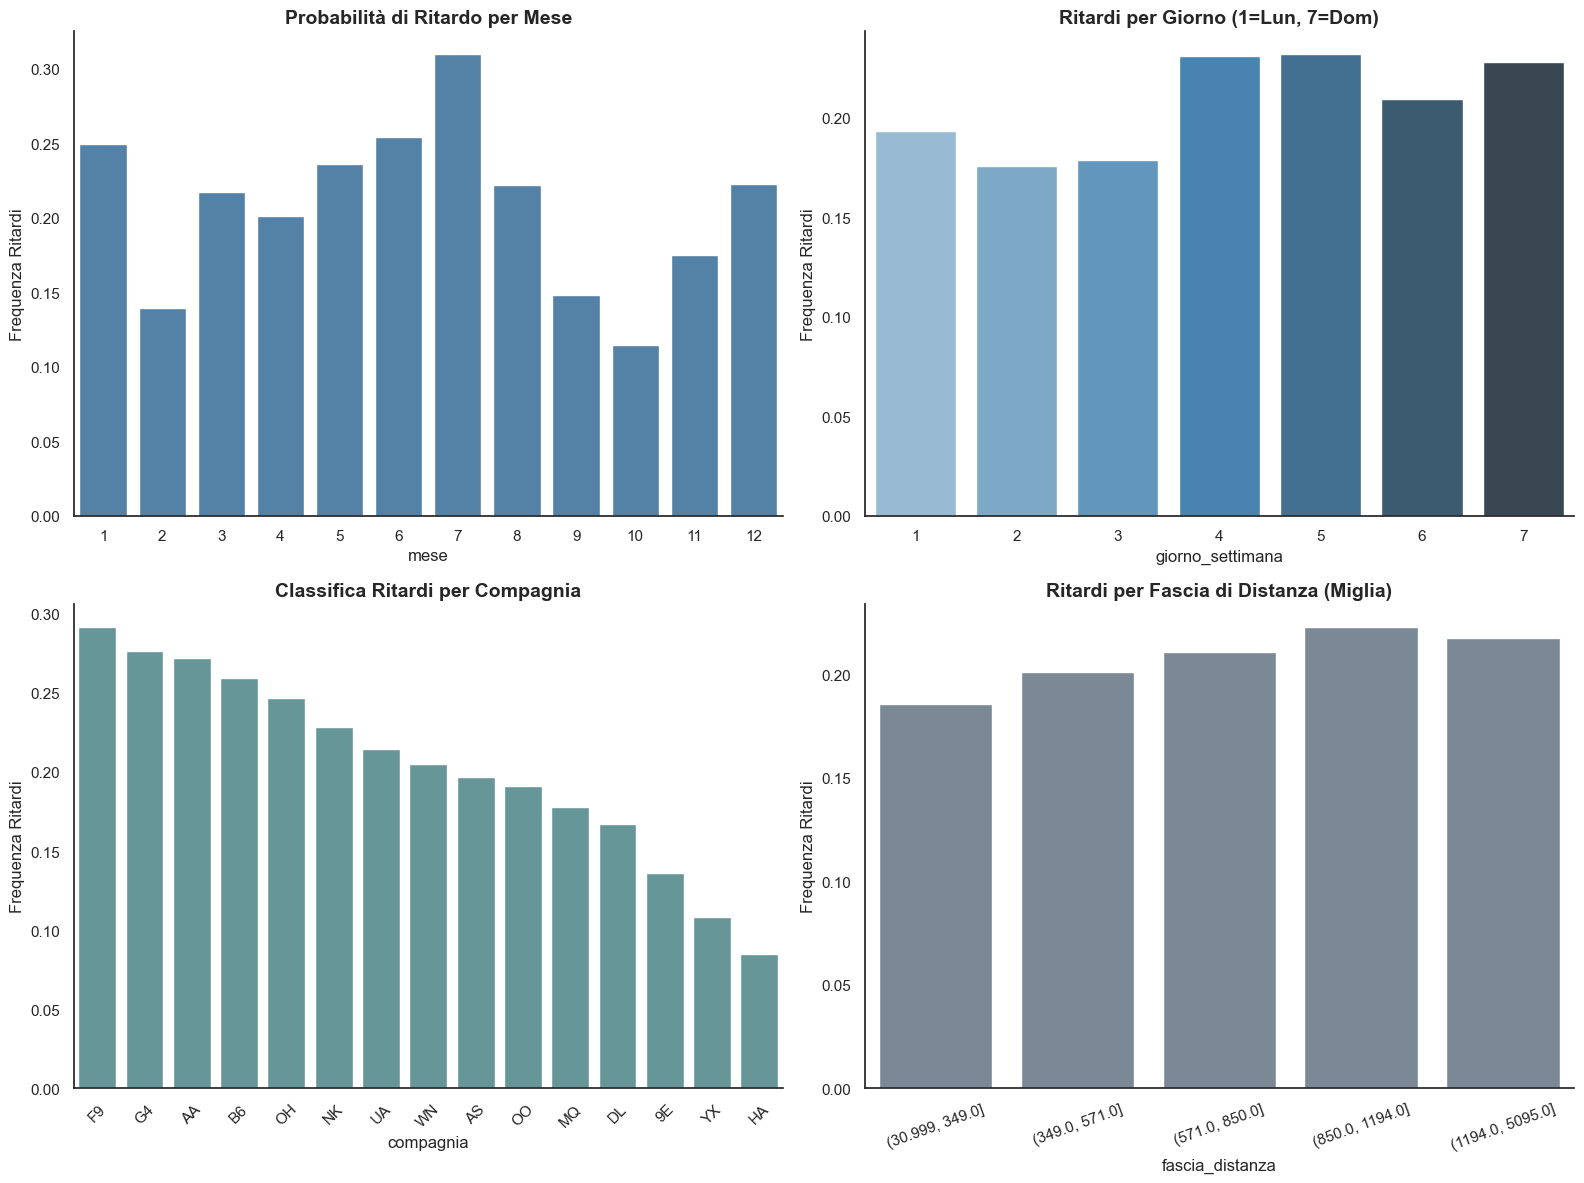

In [141]:
# --- STEP 2: VISUALIZZAZIONE ---
sns.set_theme(style="white") 
plt.figure(figsize=(16, 12))

# Grafico 1: Mese
plt.subplot(2, 2, 1)
sns.barplot(data=df, x='mese', y='in_ritardo', errorbar=None, color="steelblue")
plt.title('Probabilità di Ritardo per Mese', fontsize=14, fontweight='bold')
plt.ylabel('Frequenza Ritardi')

# Grafico 2: Giorno della Settimana
plt.subplot(2, 2, 2)
sns.barplot(data=df, x='giorno_settimana', y='in_ritardo', errorbar=None, palette="Blues_d")
plt.title('Ritardi per Giorno (1=Lun, 7=Dom)', fontsize=14, fontweight='bold')
plt.ylabel('Frequenza Ritardi')

# Grafico 3: Compagnie (Top 10 o tutte)
plt.subplot(2, 2, 3)
col_comp = 'compagnia' if 'compagnia' in df.columns else 'op_unique_carrier'
order = df.groupby(col_comp)['in_ritardo'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x=col_comp, y='in_ritardo', order=order, errorbar=None, color="cadetblue")
plt.title('Classifica Ritardi per Compagnia', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Frequenza Ritardi')

# Grafico 4: Fasce di Distanza
plt.subplot(2, 2, 4)
col_dist = 'distanza' if 'distanza' in df.columns else 'distance'
df['fascia_distanza'] = pd.qcut(df[col_dist], q=5) # Dividiamo in 5 gruppi equi
sns.barplot(data=df, x='fascia_distanza', y='in_ritardo', errorbar=None, color="lightslategray")
plt.title('Ritardi per Fascia di Distanza (Miglia)', fontsize=14, fontweight='bold')
plt.xticks(rotation=20)
plt.ylabel('Frequenza Ritardi')

sns.despine() # Rende il look più moderno e pulito
plt.tight_layout()
plt.show()

In [142]:
# Analizziamo tutte le medie storiche rispetto al target
analisi_medie = df.groupby('in_ritardo')[[
    'media_meteo_orig', 
    'media_ritardo_compagnia', 
    'media_traffico_orig', 
    'media_sicurezza_orig', 
    'media_ritardo_prec', 
    'media_durata_rotta'
]].mean()

print(analisi_medie)

            media_meteo_orig  media_ritardo_compagnia  media_traffico_orig  \
in_ritardo                                                                   
0                   1.038468                 4.904872             2.987406   
1                   1.340739                 5.132656             3.422150   

            media_sicurezza_orig  media_ritardo_prec  media_durata_rotta  
in_ritardo                                                                
0                       0.008703            5.826561          114.463524  
1                       0.009879            7.842220          119.198218  


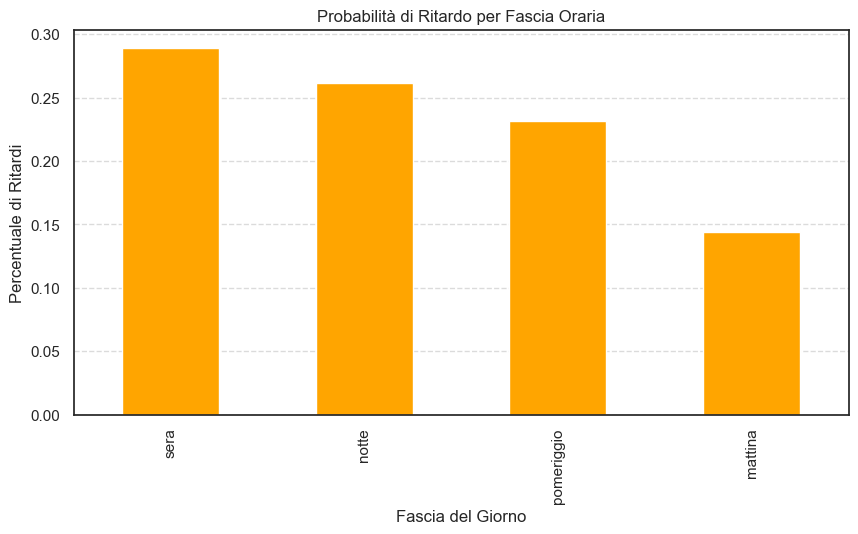

Percentuali esatte:
fascia_partenza
sera          0.288984
notte         0.261830
pomeriggio    0.231844
mattina       0.143842
Name: in_ritardo, dtype: float64


In [143]:
import matplotlib.pyplot as plt

# Calcoliamo la percentuale di ritardi (media della colonna 0/1) per ogni fascia
ritardo_fascia = df.groupby('fascia_partenza')['in_ritardo'].mean().sort_values(ascending=False)

# Creiamo il grafico
plt.figure(figsize=(10, 5))
ritardo_fascia.plot(kind='bar', color='orange')
plt.title('Probabilità di Ritardo per Fascia Oraria')
plt.ylabel('Percentuale di Ritardi')
plt.xlabel('Fascia del Giorno')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Percentuali esatte:")
print(ritardo_fascia)

In [144]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Trasformiamo le colonne di testo in numeri
df['compagnia_n'] = le.fit_transform(df['compagnia'])
df['rotta_n']     = le.fit_transform(df['rotta'])
df['fascia_n']    = le.fit_transform(df['fascia_partenza'])

# Ora possiamo eliminare le colonne di testo originali
df.drop(columns=['compagnia', 'rotta', 'fascia_partenza'], inplace=True)

df.head()

,mese,giorno_mese,giorno_settimana,durata_prevista,distanza,media_meteo_orig,media_ritardo_compagnia,media_traffico_orig,media_sicurezza_orig,media_ritardo_prec,media_durata_rotta,in_ritardo,fascia_distanza,compagnia_n,rotta_n,fascia_n
0,4,18,4,151.0,835.0,2.626168,2.929825,2.546729,0.0,4.393333,117.666667,0,"(571.0, 850.0]",8,1092,0
1,1,1,1,286.0,1773.0,0.952229,6.933824,3.162420,0.0,14.450226,244.142857,0,"(1194.0, 5095.0]",1,661,2
2,12,12,4,59.0,106.0,7.133333,5.632353,2.800000,0.0,3.444444,28.142857,0,"(30.999, 349.0]",0,532,0
3,4,8,1,180.0,1099.0,1.100000,3.178123,6.600000,0.0,7.244356,158.000000,0,"(850.0, 1194.0]",13,2449,2
4,2,16,5,90.0,399.0,0.014815,3.178123,1.925926,0.0,7.244356,69.500000,0,"(349.0, 571.0]",13,498,2


In [145]:
X = df.drop(columns=['in_ritardo', 'fascia_distanza', 'media_sicurezza_orig'])
y = df['in_ritardo']

print("Dataset pronto. Formato di X:", X.shape)
print("\nFeature usate:", X.columns.tolist())

Dataset pronto. Formato di X: (9836, 13)

Feature usate: ['mese', 'giorno_mese', 'giorno_settimana', 'durata_prevista', 'distanza', 'media_meteo_orig', 'media_ritardo_compagnia', 'media_traffico_orig', 'media_ritardo_prec', 'media_durata_rotta', 'compagnia_n', 'rotta_n', 'fascia_n']


In [146]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Divisione in Train (80%) e Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Scaling delle feature
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset diviso: {X_train.shape[0]} campioni di train, {X_test.shape[0]} di test.")

Dataset diviso: 7868 campioni di train, 1968 di test.


In [147]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Inizializzazione modelli
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Addestramento
model_lr.fit(X_train_scaled, y_train)
model_rf.fit(X_train_scaled, y_train)

print("Addestramento completato!")

Addestramento completato!


In [148]:
# Predizione sui dati di test
y_pred_lr = model_lr.predict(X_test_scaled)
y_pred_rf = model_rf.predict(X_test_scaled)

# Calcolo accuratezza
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuratezza Logistic Regression: {acc_lr:.2%}")
print(f"Accuratezza Random Forest: {acc_rf:.2%}")

Accuratezza Logistic Regression: 79.37%
Accuratezza Random Forest: 77.74%


=== REPORT LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       0.80      1.00      0.88      1560
           1       0.56      0.02      0.04       408

    accuracy                           0.79      1968
   macro avg       0.68      0.51      0.46      1968
weighted avg       0.75      0.79      0.71      1968

=== REPORT RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.79      0.97      0.87      1560
           1       0.27      0.04      0.07       408

    accuracy                           0.78      1968
   macro avg       0.53      0.51      0.47      1968
weighted avg       0.68      0.78      0.71      1968



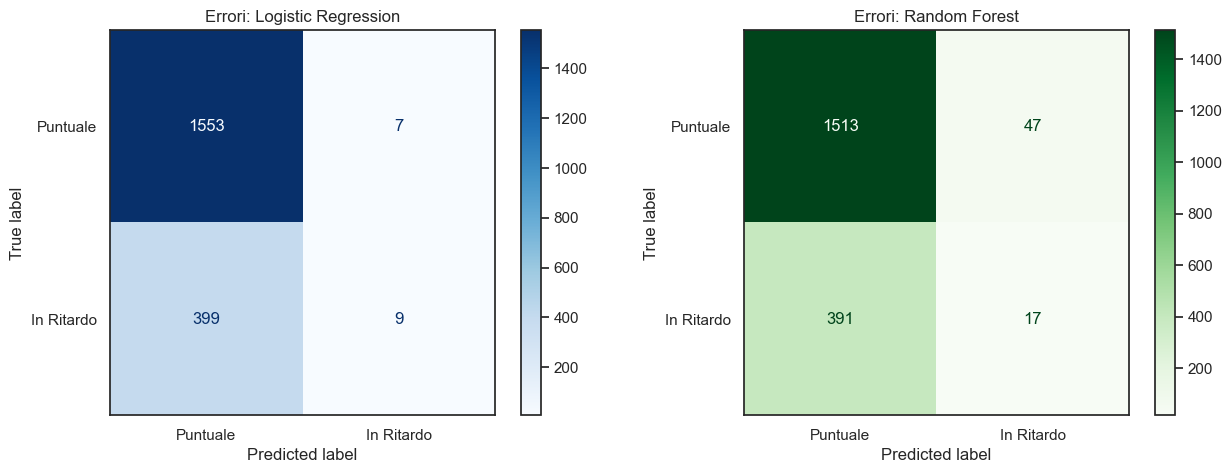

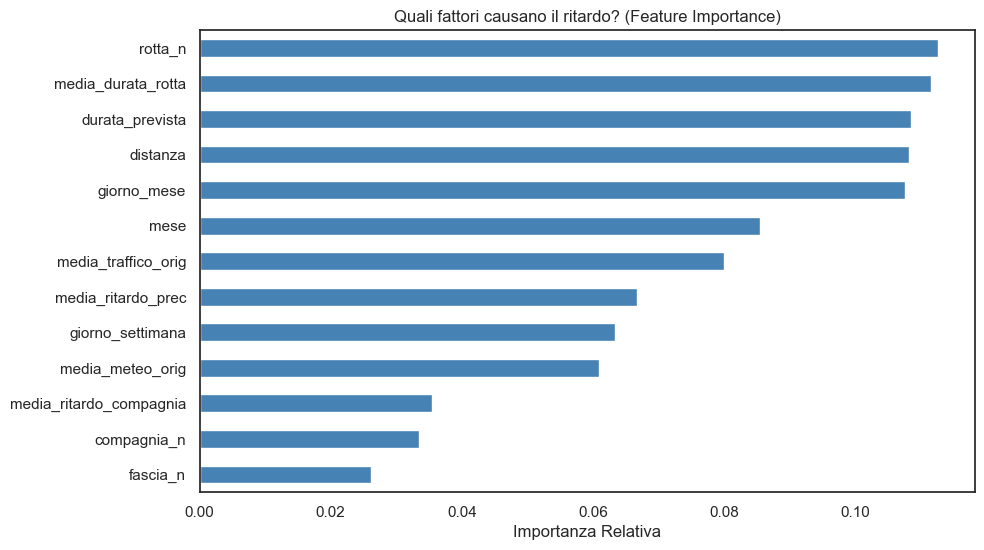

In [149]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# --- 1. REPORT TECNICO ---
print("=== REPORT LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_lr))

print("=== REPORT RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))

# --- 2. MATRICI DI CONFUSIONE (Per capire gli errori) ---
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, 
                                        display_labels=['Puntuale', 'In Ritardo'], 
                                        cmap='Blues', ax=ax[0])
ax[0].set_title('Errori: Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, 
                                        display_labels=['Puntuale', 'In Ritardo'], 
                                        cmap='Greens', ax=ax[1])
ax[1].set_title('Errori: Random Forest')

plt.show()

# --- 3. COSA HA CAPITO IL MODELLO? (Feature Importance) ---
importanze = model_rf.feature_importances_
feat_imp = pd.Series(importanze, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Quali fattori causano il ritardo? (Feature Importance)')
plt.xlabel('Importanza Relativa')
plt.show()